## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from scipy.stats import jarque_bera

import warnings
warnings.filterwarnings("ignore")

## Data Loading

In [2]:
df=pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\House Sales Price Prediction\Dataset_1\train.csv', low_memory=False)
pd.set_option('display.max_columns', None)
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Information

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Check data types

In [4]:
df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

## Target Variable Analysis

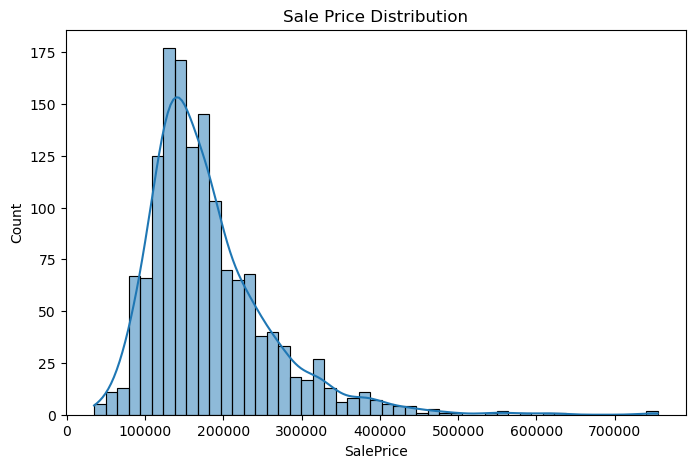

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()

### Check skewness

In [6]:
print("Skewness:", df["SalePrice"].skew())

Skewness: 1.8828757597682129


### Log transformation

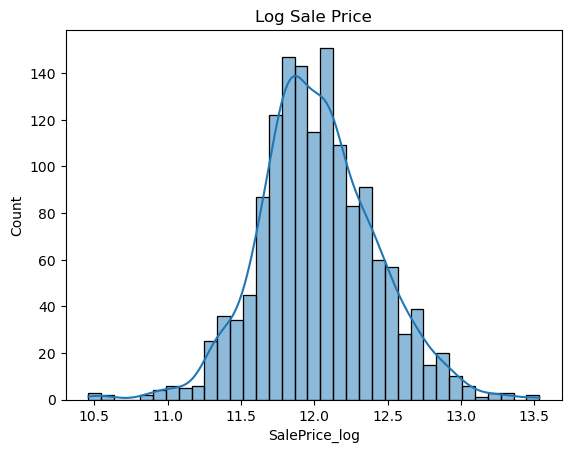

In [7]:
df["SalePrice_log"] = np.log(df["SalePrice"])
sns.histplot(df["SalePrice_log"], kde=True)
plt.title("Log Sale Price")
plt.show()

## Define Variable Types

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()


In [9]:
df.dtypes.value_counts()

object     43
int64      35
float64     4
Name: count, dtype: int64

## Recalculate column types

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

### Remove target variable

In [11]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## Missing Value Imputation

In [12]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [13]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(col, df[col].nunique())

MSZoning 5
Street 2
Alley 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 3
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 4
BsmtCond 4
BsmtExposure 4
BsmtFinType1 6
BsmtFinType2 6
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 5
GarageType 6
GarageFinish 3
GarageQual 5
GarageCond 5
PavedDrive 3
PoolQC 3
Fence 4
MiscFeature 4
SaleType 9
SaleCondition 6


## Categorical Vairable Feature Engineering

### Reduce Exterior Types

In [14]:
top_ext = df["Exterior1st"].value_counts().index[:5]

df["Exterior_grp_1"] = df["Exterior1st"].apply(
    lambda x: x if x in top_ext else "Other"
)

In [15]:
top_ext = df["Exterior2nd"].value_counts().index[:5]

df["Exterior_grp_2"] = df["Exterior2nd"].apply(
    lambda x: x if x in top_ext else "Other"
)

In [16]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(col, df[col].nunique())

MSZoning 5
Street 2
Alley 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 3
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 4
BsmtCond 4
BsmtExposure 4
BsmtFinType1 6
BsmtFinType2 6
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 5
GarageType 6
GarageFinish 3
GarageQual 5
GarageCond 5
PavedDrive 3
PoolQC 3
Fence 4
MiscFeature 4
SaleType 9
SaleCondition 6
Exterior_grp_1 6
Exterior_grp_2 6


### Reduce Neighborhood Levels

In [17]:
top_neigh = df["Neighborhood"].value_counts().index[:8]

df["Neighborhood_grp"] = df["Neighborhood"].apply(
    lambda x: x if x in top_neigh else "Other"
)

## Exploratory Analysis

### Scatter Plot

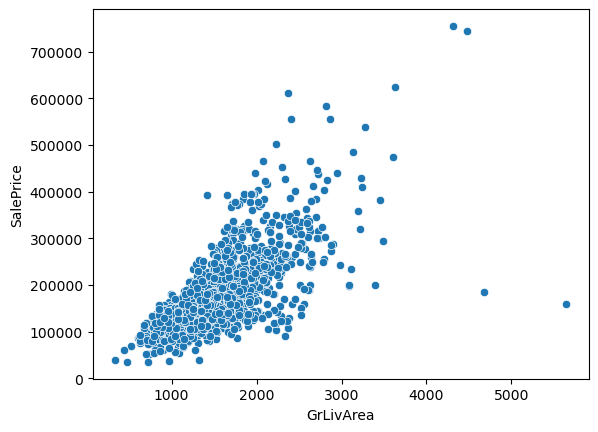

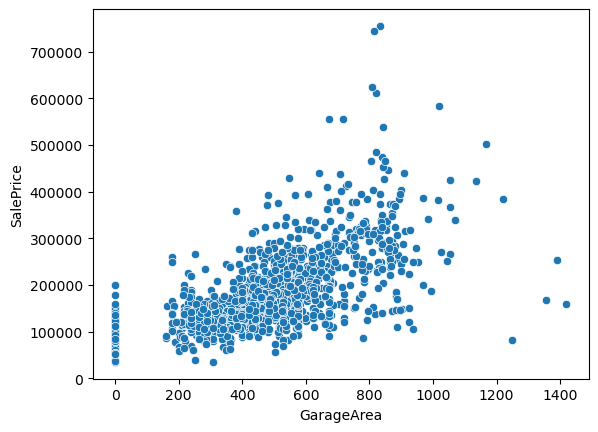

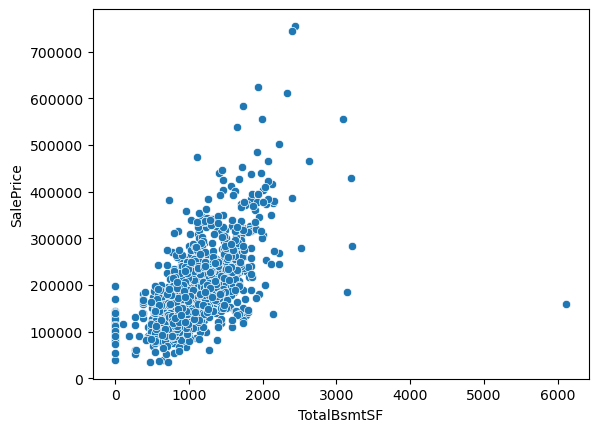

In [18]:
features = ["GrLivArea","GarageArea","TotalBsmtSF"]

for f in features:
    sns.scatterplot(x=df[f], y=df["SalePrice"])
    plt.show()

### Boxplot for categorical variables

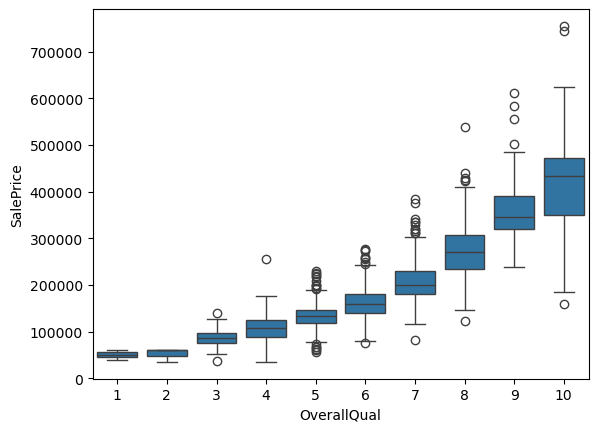

In [19]:
sns.boxplot(x=df["OverallQual"], y=df["SalePrice"])
plt.show()

## Outlier Analysis

#### Boxplot

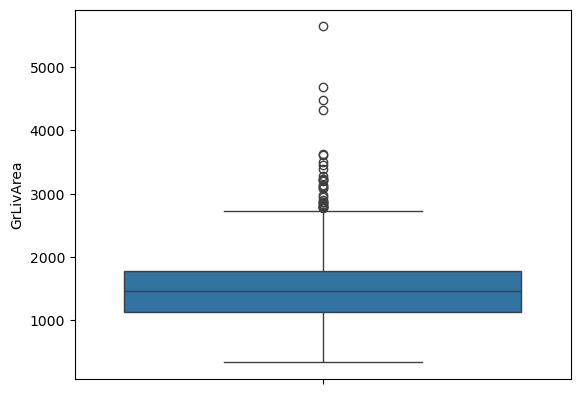

In [20]:
sns.boxplot(df["GrLivArea"])
plt.show()

#### Outlier Detection (IQR Method)

In [21]:
Q1 = df["GrLivArea"].quantile(0.25)
Q3 = df["GrLivArea"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["GrLivArea"] > lower) & (df["GrLivArea"] < upper)]

In [22]:
X = df.drop(["SalePrice_log","Id","YearBuilt","YearRemodAdd","YrSold"], axis=1)

y = df["SalePrice_log"]

## Correlation Analysis

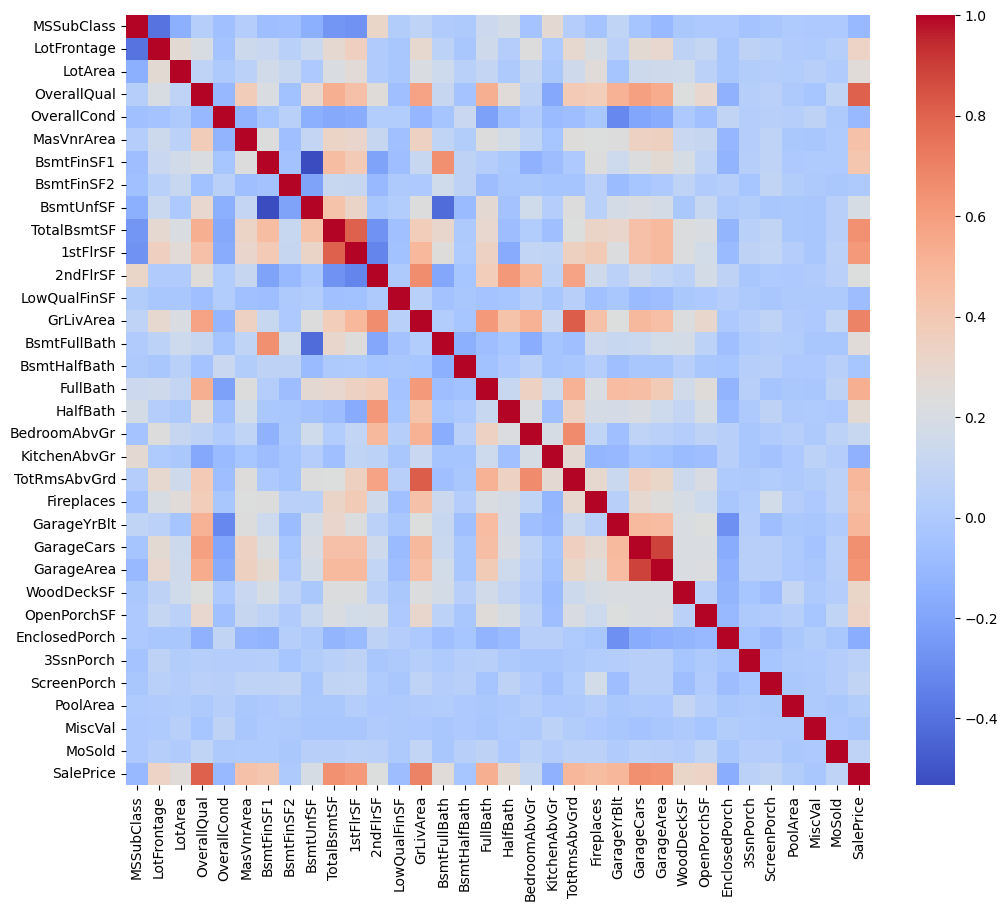

In [23]:
numeric_X = X.select_dtypes(include=np.number)
corr = numeric_X.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

### Top Correlation with Target

In [24]:
corr_target = corr["SalePrice"].sort_values(ascending=False)
corr_target.head(15)

SalePrice       1.000000
OverallQual     0.804186
GrLivArea       0.696162
GarageCars      0.654766
TotalBsmtSF     0.648681
GarageArea      0.638838
1stFlrSF        0.615310
FullBath        0.528040
GarageYrBlt     0.496169
TotRmsAbvGrd    0.495099
Fireplaces      0.465247
MasVnrArea      0.442265
BsmtFinSF1      0.416804
LotFrontage     0.334599
OpenPorchSF     0.330455
Name: SalePrice, dtype: float64

In [25]:
X = df.drop("SalePrice", axis=1)

## Re-Define X and y

In [26]:
X = df.drop(["SalePrice", "SalePrice_log", "Id"], axis=1)
y = df["SalePrice_log"]


 ## Train-Test Split



In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1143, 82)
Test shape: (286, 82)


#### Keep only numeric variables

In [28]:

X_num = X_train.select_dtypes(include=np.number)

## VIF Calulation and High VIF removal Function

In [29]:
def calculate_vif(X, threshold=5):

    while True:

        vif = pd.DataFrame()
        vif["Variable"] = X.columns
        vif["VIF"] = [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]

        max_vif = vif["VIF"].max()

        if max_vif > threshold:

            drop_var = vif.sort_values("VIF", ascending=False)["Variable"].iloc[0]

            if drop_var == "const":
                break

            print("Dropping:", drop_var, "VIF:", max_vif)

            X = X.drop(columns=[drop_var])

        else:
            break

    return X


### Run VIF Function

In [30]:
# Add constant
X_num = sm.add_constant(X_num)
# Run VIF
X_vif = calculate_vif(X_num, threshold=5)
print("Remaining variables after VIF:")
print(X_vif.columns)

Dropping: LowQualFinSF VIF: inf
Dropping: BsmtFinSF1 VIF: inf
Remaining variables after VIF:
Index(['const', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')


### Convert categorical variables

In [31]:

X_cat = pd.get_dummies(X_train, drop_first=True).astype(int)

In [32]:
X = pd.concat([X_vif, X_cat], axis=1)

##### Add constant

In [33]:
X = sm.add_constant(X)

## Stepwise Multiple Regression (Backward Elimination)

In [35]:
X_model = sm.add_constant(X)

def backward_elimination(X, y, significance_level=0.05):

    X = X.copy()

    while True:

        model = sm.OLS(y, X).fit()

        # drop constant safely
        pvalues = model.pvalues.drop("const", errors="ignore")

        max_p = pvalues.max()

        if max_p > significance_level:

            drop_var = pvalues.idxmax()

            print(f"Dropping {drop_var} (p-value = {max_p:.4f})")

            X = X.drop(columns=[drop_var])

        else:
            break

    model = sm.OLS(y, X).fit()

    return model, X


# Run stepwise regression
model, X_final = backward_elimination(X_model, y_train)

print(model.summary())

print("\n Model Summary")
print(model.summary())

Dropping SaleType_WD (p-value = 0.9865)
Dropping Fence_MnWw (p-value = 0.9819)
Dropping BsmtFinType2_LwQ (p-value = 0.9783)
Dropping RoofMatl_WdShake (p-value = 0.9761)
Dropping Exterior1st_Stone (p-value = 0.9742)
Dropping Exterior2nd_Stone (p-value = 0.9775)
Dropping GarageCond_TA (p-value = 0.9696)
Dropping RoofStyle_Hip (p-value = 0.9549)
Dropping BldgType_TwnhsE (p-value = 0.9513)
Dropping Exterior1st_ImStucc (p-value = 0.9534)
Dropping HouseStyle_SFoyer (p-value = 0.9354)
Dropping HouseStyle_SLvl (p-value = 0.9572)
Dropping SaleType_ConLI (p-value = 0.9356)
Dropping LotConfig_FR3 (p-value = 0.9301)
Dropping RoofMatl_Roll (p-value = 0.9277)
Dropping Exterior1st_WdShing (p-value = 0.9130)
Dropping RoofStyle_Gable (p-value = 0.9147)
Dropping MiscVal (p-value = 0.8955)
Dropping Condition2_RRAn (p-value = 0.8675)
Dropping HouseStyle_1.5Unf (p-value = 0.8444)
Dropping MiscFeature_Shed (p-value = 0.8478)
Dropping MoSold (p-value = 0.8494)
Dropping Neighborhood_NoRidge (p-value = 0.8430)

## Model Diagnostics

#### Heteroskedasticity Test

In [36]:
bp_test = het_breuschpagan(model.resid, model.model.exog)

bp_labels = [
    "Lagrange multiplier statistic",
    "p-value",
    "f-value",
    "f p-value"
]

print(dict(zip(bp_labels, bp_test)))

{'Lagrange multiplier statistic': np.float64(220.33692551801735), 'p-value': np.float64(2.4912799404681143e-08), 'f-value': np.float64(3.08699664747183), 'f p-value': np.float64(9.706036567418119e-17)}


#### Normality Test

In [37]:

jb_test = jarque_bera(model.resid)

print("Jarque-Bera:", jb_test)

Jarque-Bera: SignificanceResult(statistic=np.float64(948.4948177520433), pvalue=np.float64(1.0888480262814167e-206))


#### Ramsey RESET Test

In [38]:
reset = linear_reset(model, power=2, use_f=True)

print(reset)

<F test: F=5.834924747575591, p=0.015879546357865357, df_denom=1.06e+03, df_num=1>


##### Residual plot

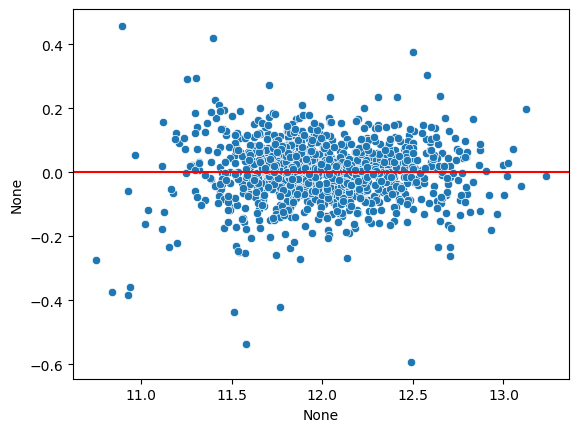

In [39]:

residuals = model.resid

sns.scatterplot(x=model.fittedvalues, y=residuals)

plt.axhline(0,color="red")

plt.show()

#### Normality of residuals

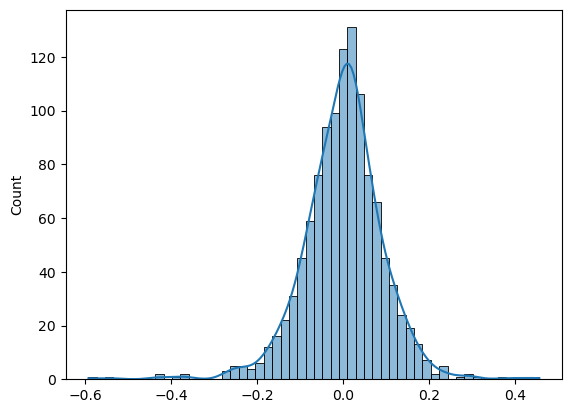

In [40]:
sns.histplot(residuals, kde=True)

plt.show()

### Predicted vs Actual

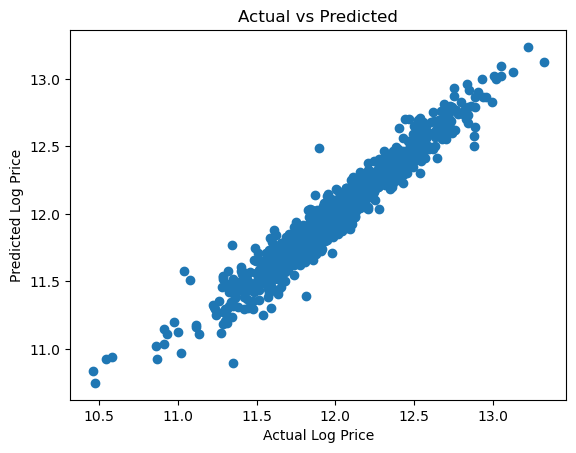

In [41]:
pred = model.predict(X_final)

plt.scatter(y_train, pred)

plt.xlabel("Actual Log Price")

plt.ylabel("Predicted Log Price")

plt.title("Actual vs Predicted")

plt.show()

## Prepare Test Data

In [42]:
# numeric variables used after VIF
test_subset = X_test[X_test.columns.intersection(X_vif.columns)]

# encode only categorical variables
test_cat = pd.get_dummies(
    X_test.select_dtypes(include="object"),
    drop_first=True
)

# combine numeric + categorical
test_sample = pd.concat([test_subset, test_cat], axis=1)

# align columns with training model
X_test_final = test_sample.reindex(
    columns=X_final.columns.drop("const"),
    fill_value=0
)

# add constant
X_test_final = sm.add_constant(X_test_final)


## Predict on Test Data

In [43]:
y_pred = model.predict(X_test_final)

## Prediction Error Metrics

In [44]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 0.12427230254410745
Test MAE: 0.08449062616253147


## Actual vs Predicted Plot

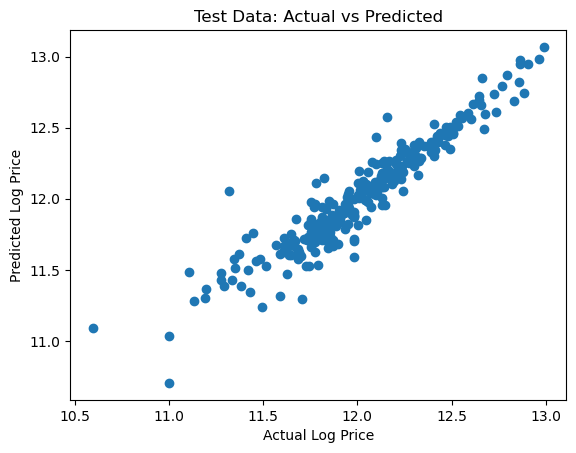

In [45]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")

plt.title("Test Data: Actual vs Predicted")

plt.show()

# Random Forest Model 

In [47]:
from sklearn.ensemble import RandomForestRegressor
# Remove constant column if present
X_train_model = X.drop(columns=["const"], errors="ignore")

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_model, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Feature Importance

OverallQual         0.267932
OverallQual         0.266146
GrLivArea           0.061434
GrLivArea           0.058165
BsmtFinSF1          0.037917
TotalBsmtSF         0.022914
TotalBsmtSF         0.022247
GarageCars          0.016207
GarageArea          0.016124
GarageArea          0.014573
CentralAir_Y        0.012365
1stFlrSF            0.011236
GarageCars          0.011204
1stFlrSF            0.010392
GarageFinish_Unf    0.008704
YearBuilt           0.008088
OverallCond         0.007830
YearBuilt           0.007396
LotArea             0.006995
OverallCond         0.006983
dtype: float64


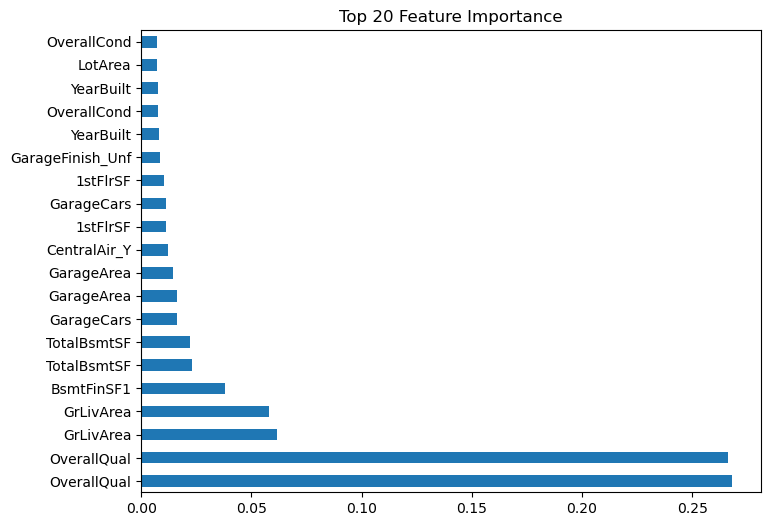

In [48]:
feature_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_train_model.columns
).sort_values(ascending=False)

print(feature_imp.head(20))

plt.figure(figsize=(8,6))
feature_imp.head(20).plot(kind="barh")
plt.title("Top 20 Feature Importance")
plt.show()

## Prediction on Train Data

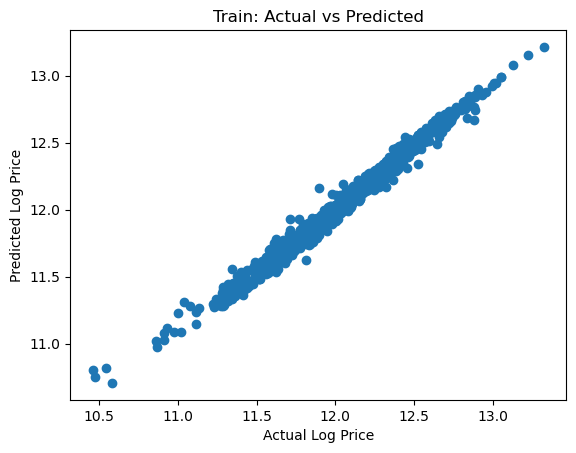

In [49]:
train_pred = rf_model.predict(X_train_model)

plt.scatter(y_train, train_pred)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Train: Actual vs Predicted")
plt.show()

## Prepare Test Data

In [50]:
test_subset = X_test[X_test.columns.intersection(X_vif.columns)]

test_cat = pd.get_dummies(
    X_test.select_dtypes(include="object"),
    drop_first=True
)

test_sample = pd.concat([test_subset, test_cat], axis=1)

X_test_final = test_sample.reindex(
    columns=X_train_model.columns,
    fill_value=0
)

##  Predict on Test Data

In [51]:
y_pred = rf_model.predict(X_test_final)

## Model Evaluation

In [52]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 0.1473189751494056
Test MAE: 0.10009781689940478


## Actual vs Predicted Plot

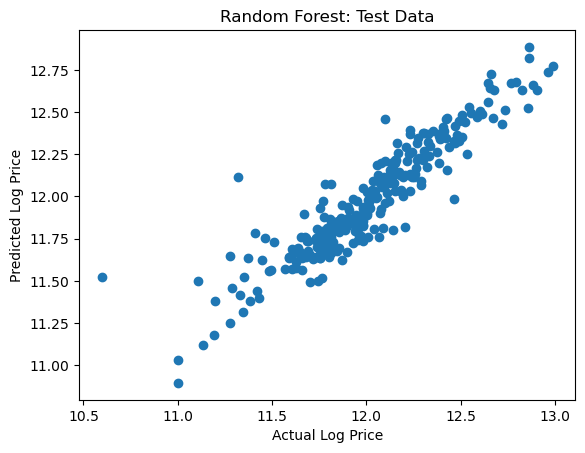

In [53]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Random Forest: Test Data")

plt.show()

# XGBoost Model

In [56]:
from xgboost import XGBRegressor


# remove constant column
X_train_model = X_final.drop(columns=["const"], errors="ignore")

# ensure numeric
X_train_model = X_train_model.astype(float)

# convert to numpy (important)
X_train_model = X_train_model.values

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_model, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Feature Importance

OverallQual             0.419985
OverallQual             0.112463
GarageCars              0.048331
CentralAir_Y            0.043366
KitchenAbvGr            0.022666
GarageCars              0.021678
OverallCond             0.018919
GrLivArea               0.017638
MSZoning_RM             0.016041
GrLivArea               0.013734
Fireplaces              0.013007
KitchenQual_TA          0.012026
Neighborhood_OldTown    0.011608
TotalBsmtSF             0.010095
YearBuilt               0.009025
TotalBsmtSF             0.008877
PavedDrive_Y            0.008866
Fireplaces              0.008394
BsmtExposure_Gd         0.007245
Neighborhood_Crawfor    0.006572
dtype: float32


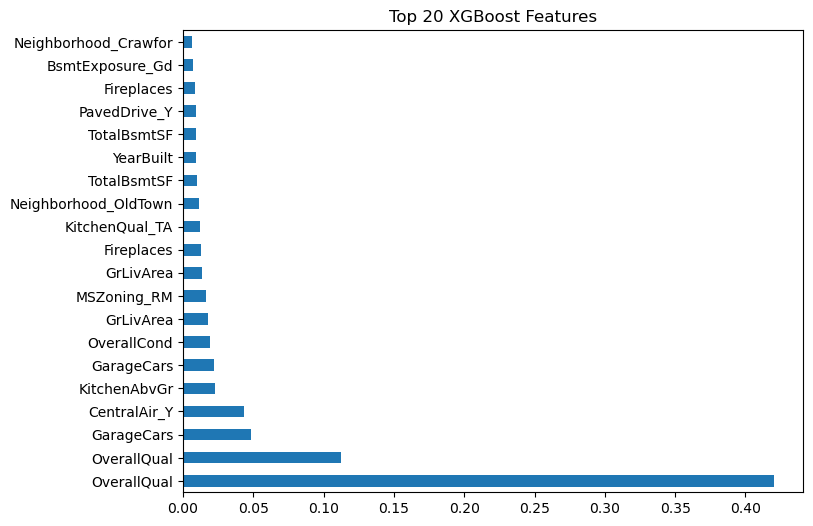

In [58]:
#Save feature names before conversion
feature_names = X_final.drop(columns=["const"], errors="ignore").columns
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(20))

plt.figure(figsize=(8,6))
importance.head(20).plot(kind="barh")
plt.title("Top 20 XGBoost Features")
plt.show()

## Train Prediction Plot

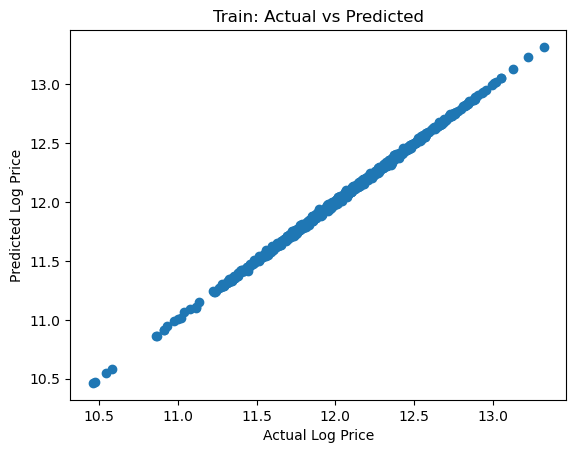

In [59]:
train_pred = xgb_model.predict(X_train_model)

plt.scatter(y_train, train_pred)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")

plt.title("Train: Actual vs Predicted")

plt.show()

## Prepare Test Data

In [61]:
test_subset = X_test[X_test.columns.intersection(X_vif.columns)]

test_cat = pd.get_dummies(
    X_test.select_dtypes(include="object"),
    drop_first=True
)

test_sample = pd.concat([test_subset, test_cat], axis=1)

X_test_final = test_sample.reindex(
    columns=feature_names,
    fill_value=0
)

#Convert to numeric before prediction


X_test_final = X_test_final.astype(float)
X_test_final = X_test_final.values




## Predict on Test Data

In [62]:
y_pred = xgb_model.predict(X_test_final)

## Evaluation

In [63]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 0.13253483649405082
Test MAE: 0.08756973762976661


## Actual vs Predicted Plot

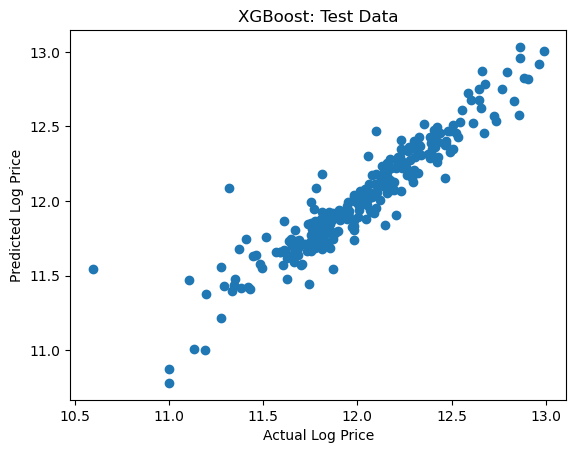

In [64]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")

plt.title("XGBoost: Test Data")

plt.show()